# 13 — Stance Time Series & Model Disagreement

1. Net hawk score over time — one panel per bank, one line per model
2. Chunk-level agreement rate and disagreement categories
3. Temporal disagreement — meeting-level score gap
4. Turning point agreement
5. Delta/shift analysis — meeting-to-meeting changes
6. Semantic representation space (embeddings)
7. Disagreement by linguistic features (logistic regression)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

ROOT    = Path('..').resolve()
OUT_DIR = ROOT / 'output' / 'stance'

BANKS = ['BoE', 'ECB', 'Fed']

STANCE_SCORE = {
    'dovish':        -1.0,
    'mostly dovish': -0.5,
    'neutral':        0.0,
    'mostly hawkish': 0.5,
    'hawkish':        1.0,
}
CONFIDENCE_SCORE = {'low': 1, 'medium': 2, 'high': 3}
DIRECTION_MAP = {
    'dovish': 'dovish', 'mostly dovish': 'dovish',
    'neutral': 'neutral',
    'mostly hawkish': 'hawkish', 'hawkish': 'hawkish',
}
DIRECTIONAL = ['dovish', 'mostly dovish', 'mostly hawkish', 'hawkish']

# Add models here as they finish
MODELS = {
    'llama33':         {'label': 'Llama 3.3 70B',   'color': '#4C72B0', 'ls': '-'},
    'deepseekv3':      {'label': 'DeepSeek V3',      'color': '#DD8452', 'ls': '-'},
    'qwen25_72b':      {'label': 'Qwen 2.5 72B',     'color': '#55A868', 'ls': '-'},
    'mistrallarge_or': {'label': 'Mistral Large',    'color': '#C44E52', 'ls': '-'},
}

## 1. Load & aggregate all models

In [2]:
def load_predictions(model_key):
    path = OUT_DIR / f'chunk_predictions_{model_key}.csv'
    if not path.exists():
        print(f'  {model_key}: not found, skipping')
        return None
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'].astype(str), format='%Y%m%d')
    valid = df['label'].isin(STANCE_SCORE) & df['confidence'].isin(CONFIDENCE_SCORE)
    n_err = (~valid).sum()
    if n_err:
        print(f'  {model_key}: dropping {n_err} parse_error rows ({n_err/len(df):.1%})')
    df = df[valid].copy()
    df['score'] = df['label'].map(STANCE_SCORE)
    df['conf_numeric'] = df['confidence'].map(CONFIDENCE_SCORE)
    print(f'  {model_key}: {len(df):,} chunks, {df["doc_id"].nunique()} meetings')
    return df


def aggregate_meetings(df):
    rows = []
    for (bank, doc_id, date), grp in df.groupby(['bank', 'doc_id', 'date']):
        n  = len(grp)
        H  = (grp['label'] == 'hawkish').sum()
        MH = (grp['label'] == 'mostly hawkish').sum()
        D  = (grp['label'] == 'dovish').sum()
        MD = (grp['label'] == 'mostly dovish').sum()
        hawk_mass = H + 0.5 * MH
        dove_mass = D + 0.5 * MD
        wi = grp['n_sentences'].fillna(1)
        rows.append({
            'bank':          bank,
            'doc_id':        doc_id,
            'date':          date,
            'n_chunks':      n,
            'net_hawk':      (hawk_mass - dove_mass) / n,
            'logit':         np.log((hawk_mass + 0.5) / (dove_mass + 0.5)),
            'wtd_net_hawk':  (wi * grp['score']).sum() / wi.sum(),
            'mean_conf':     grp['conf_numeric'].mean(),
            'pct_high_conf': (grp['confidence'] == 'high').mean(),
        })
    return pd.DataFrame(rows).sort_values(['bank', 'date'])


print('Loading models:')
all_chunks   = {}
all_meetings = {}
for key in MODELS:
    df = load_predictions(key)
    if df is not None:
        all_chunks[key]   = df
        all_meetings[key] = aggregate_meetings(df)

loaded = list(all_chunks.keys())
print(f'\nLoaded: {loaded}')
if len(loaded) >= 2:
    key_a, key_b   = loaded[0], loaded[1]
    label_a, label_b = MODELS[key_a]['label'], MODELS[key_b]['label']

Loading models:
  llama33: 5,004 chunks, 204 meetings
  deepseekv3: dropping 6 parse_error rows (0.1%)
  deepseekv3: 4,998 chunks, 204 meetings

Loaded: ['llama33', 'deepseekv3']


## 2. Net hawk score over time

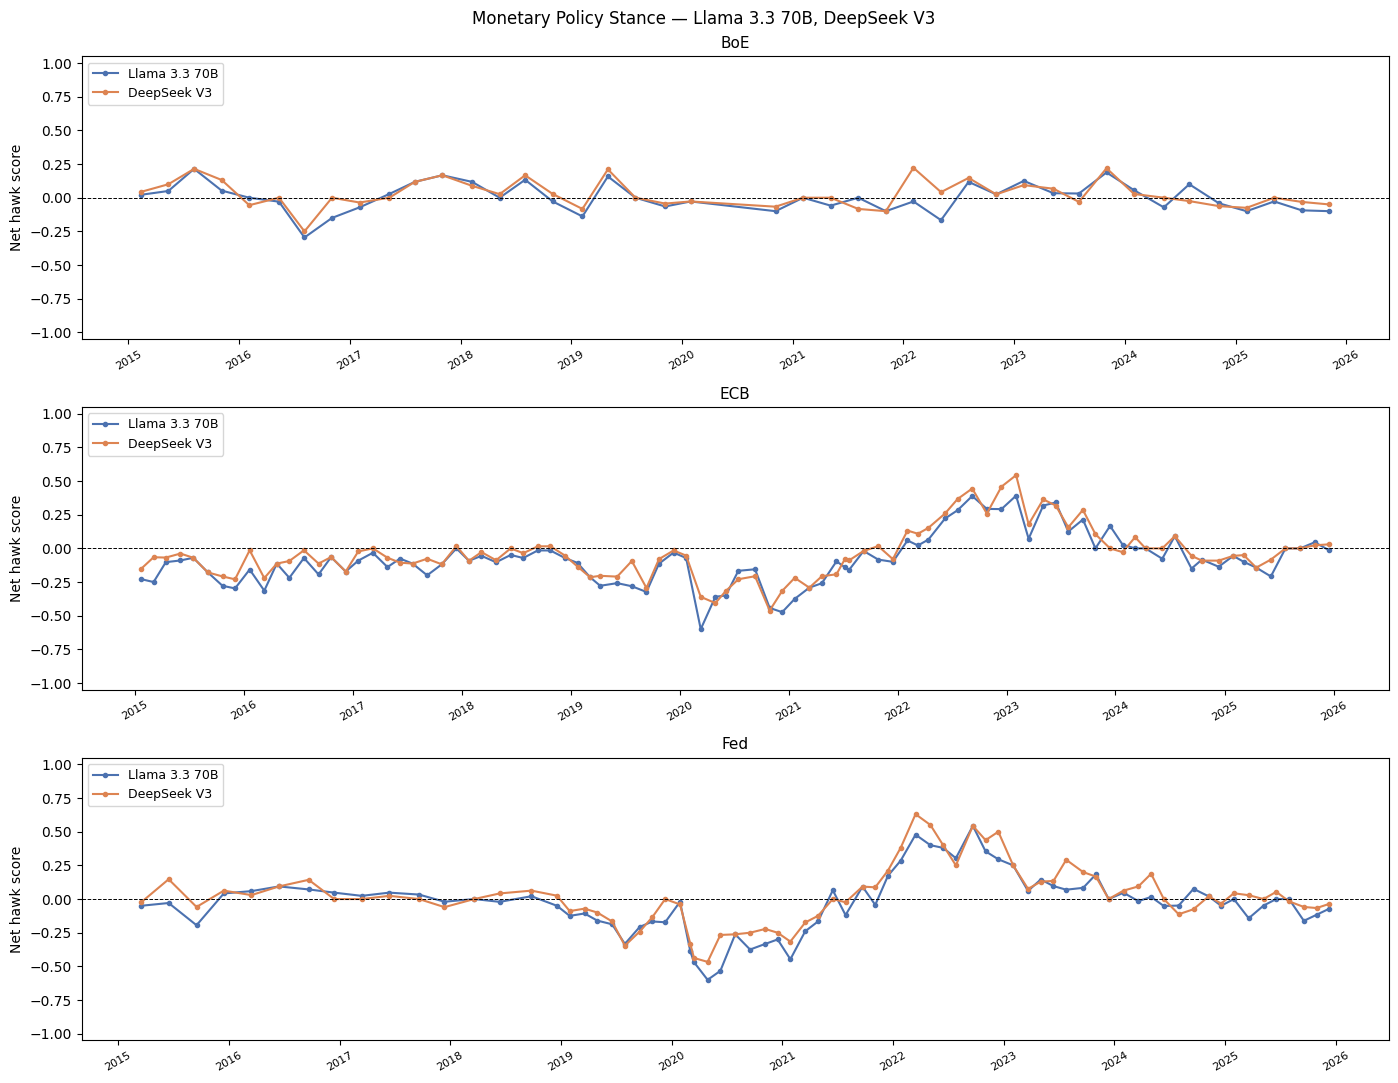

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
for ax, bank in zip(axes, BANKS):
    for key, meta in MODELS.items():
        if key not in all_meetings:
            continue
        bdf = all_meetings[key][all_meetings[key]['bank'] == bank].sort_values('date')
        ax.plot(bdf['date'], bdf['net_hawk'], color=meta['color'], linestyle=meta['ls'],
                linewidth=1.5, marker='o', markersize=3, label=meta['label'])
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_title(bank, fontsize=11)
    ax.set_ylabel('Net hawk score')
    ax.set_ylim(-1.05, 1.05)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.legend(fontsize=9, loc='upper left')

model_labels = ', '.join(MODELS[k]['label'] for k in all_meetings)
out_name = '_'.join(all_meetings.keys())
plt.suptitle(f'Monetary Policy Stance — {model_labels}', fontsize=12)
plt.tight_layout()
plt.savefig(OUT_DIR / f'timeseries_net_hawk_{out_name}.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Chunk-level agreement

In [4]:
if len(loaded) < 2:
    print(f'Need 2 models, only {len(loaded)} loaded.')
else:
    cols = ['chunk_uid', 'bank', 'doc_id', 'date', 'label', 'score', 'confidence',
            'turn_type', 'speaker_role', 'doc_type', 'turn_idx', 'chunk_id',
            'start_sent_idx', 'end_sent_idx', 'n_sentences', 'text']
    merged = all_chunks[key_a][cols].merge(
        all_chunks[key_b][cols],
        on=['chunk_uid', 'bank', 'doc_id', 'date', 'turn_type', 'speaker_role',
            'doc_type', 'turn_idx', 'chunk_id', 'start_sent_idx', 'end_sent_idx',
            'n_sentences', 'text'],
        suffixes=(f'_{key_a}', f'_{key_b}'),
    )
    merged['same_label']    = merged[f'label_{key_a}'] == merged[f'label_{key_b}']
    merged['abs_score_gap'] = (merged[f'score_{key_a}'] - merged[f'score_{key_b}']).abs()

    print(f'=== {label_a} vs {label_b} ===')
    print(f'Exact agreement:    {merged["same_label"].mean():.1%}')
    print(f'Mean score gap:     {merged["abs_score_gap"].mean():.3f}')
    print(f'Median score gap:   {merged["abs_score_gap"].median():.3f}')
    print()
    print(merged.groupby('bank').agg(
        n_chunks=('chunk_uid','size'),
        agreement_rate=('same_label','mean'),
        mean_score_gap=('abs_score_gap','mean'),
    ).round(3))

=== Llama 3.3 70B vs DeepSeek V3 ===
Exact agreement:    77.7%
Mean score gap:     0.131
Median score gap:   0.000

      n_chunks  agreement_rate  mean_score_gap
bank                                          
BoE        739           0.816           0.104
ECB       2446           0.786           0.131
Fed       1813           0.747           0.142


In [5]:
if len(loaded) >= 2:
    disagreements = merged[~merged['same_label']].copy()
    disagreements[f'dir_{key_a}'] = disagreements[f'label_{key_a}'].map(DIRECTION_MAP)
    disagreements[f'dir_{key_b}'] = disagreements[f'label_{key_b}'].map(DIRECTION_MAP)

    conditions = [
        disagreements['abs_score_gap'] >= 1.0,
        (disagreements[f'dir_{key_a}'] == 'neutral') | (disagreements[f'dir_{key_b}'] == 'neutral'),
        disagreements[f'dir_{key_a}'] == disagreements[f'dir_{key_b}'],
    ]
    choices = ['strong directional clash', 'neutral vs directional', 'same direction, different intensity']
    disagreements['bucket'] = np.select(conditions, choices, default='other')

    n_dis = len(disagreements)
    print(f'Disagreements: {n_dis} chunks ({n_dis/len(merged):.1%})')
    for bucket, count in disagreements['bucket'].value_counts().items():
        print(f'  {bucket:<42} {count:>4}  ({count/n_dis:.1%})')
    print()
    print('Top label transition pairs:')
    print((disagreements[f'label_{key_a}'] + ' → ' + disagreements[f'label_{key_b}']).value_counts().head(10).to_string())

Disagreements: 1117 chunks (22.3%)
  neutral vs directional                      654  (58.5%)
  same direction, different intensity         291  (26.1%)
  strong directional clash                    172  (15.4%)

Top label transition pairs:
mostly dovish → neutral           313
mostly hawkish → neutral          228
mostly hawkish → hawkish          161
dovish → neutral                   82
neutral → mostly dovish            78
dovish → mostly dovish             68
mostly dovish → dovish             62
neutral → mostly hawkish           35
neutral → dovish                   27
mostly dovish → mostly hawkish     21


## 4. Temporal disagreement — meeting-level score gap

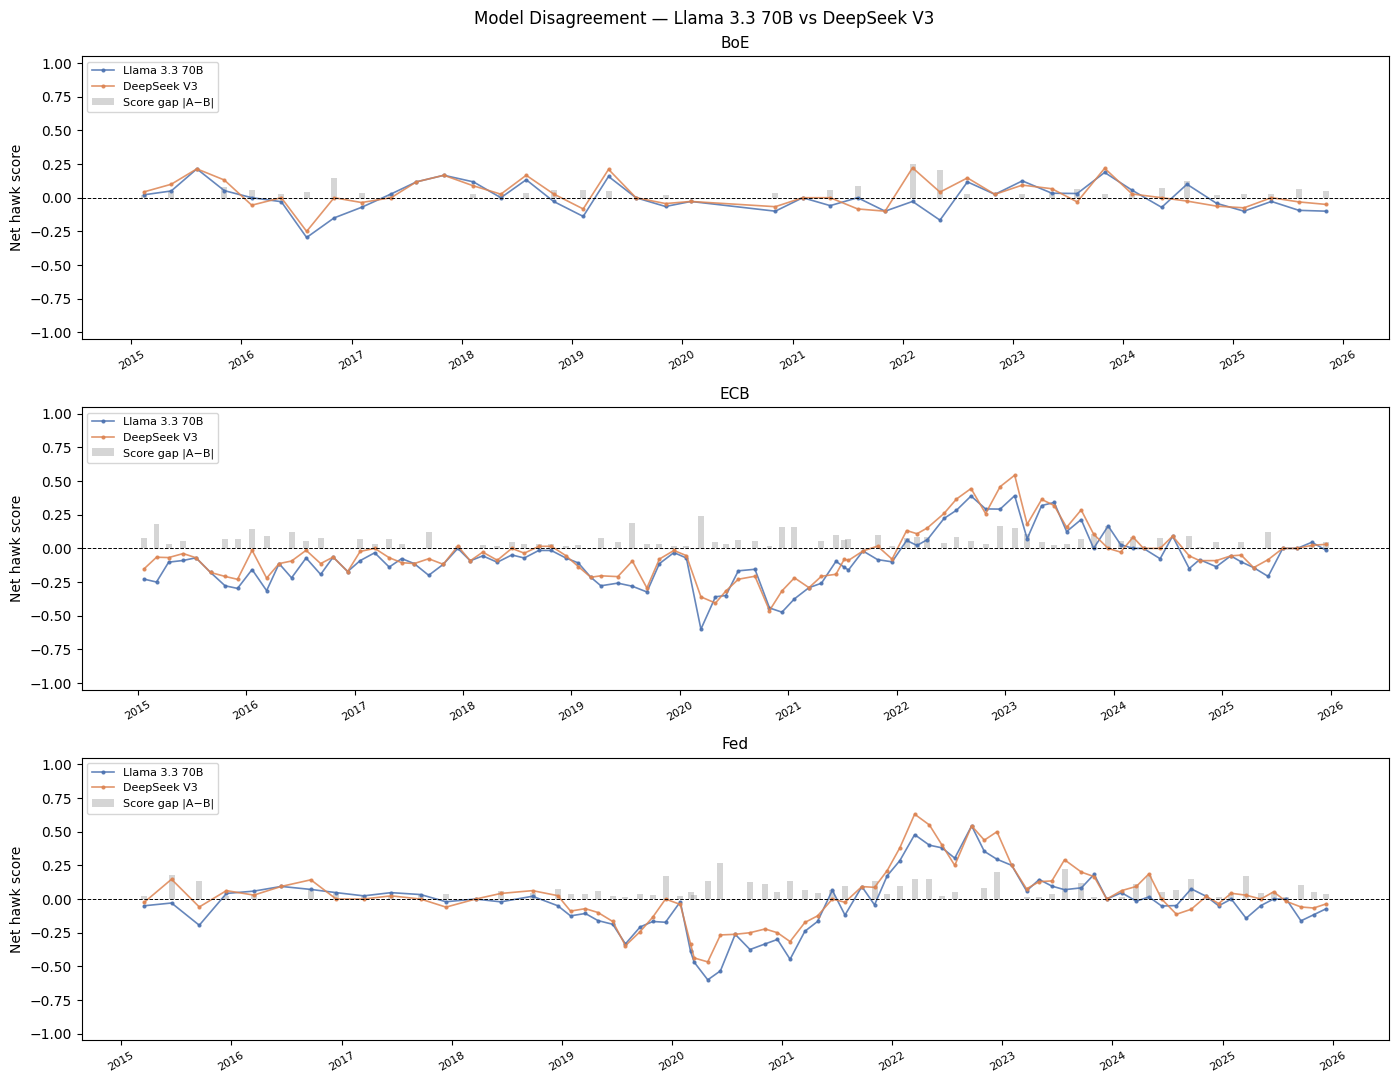

Meetings with largest score gap:
bank       date  llama33  deepseekv3  score_gap
 Fed 2020-06-10   -0.533      -0.267      0.267
 BoE 2022-02-03   -0.028       0.222      0.250
 ECB 2020-03-12   -0.600      -0.360      0.240
 Fed 2023-07-26    0.069       0.292      0.222
 BoE 2022-05-05   -0.167       0.042      0.208
 Fed 2022-12-14    0.295       0.500      0.205
 ECB 2019-07-25   -0.281      -0.094      0.188
 ECB 2015-03-05   -0.250      -0.066      0.184
 Fed 2015-06-17   -0.029       0.147      0.176
 Fed 2019-12-11   -0.172       0.000      0.172


C:\Users\sffra\AppData\Local\Temp\ipykernel_33384\3164616122.py:31: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(wide.nlargest(10, 'score_gap')[['bank','date',key_a,key_b,'score_gap']].round(3).to_string(index=False))


In [6]:
if len(loaded) >= 2:
    wide = all_meetings[key_a][['bank','doc_id','date','net_hawk']].rename(columns={'net_hawk': key_a})
    wide = wide.merge(
        all_meetings[key_b][['bank','doc_id','date','net_hawk']].rename(columns={'net_hawk': key_b}),
        on=['bank','doc_id','date'],
    )
    wide['score_gap'] = (wide[key_a] - wide[key_b]).abs()
    wide = wide.sort_values(['bank','date'])

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
    for ax, bank in zip(axes, BANKS):
        bdf = wide[wide['bank'] == bank].sort_values('date')
        ax.bar(bdf['date'], bdf['score_gap'], width=20, color='#888', alpha=0.35, label='Score gap |A−B|')
        for key, meta in {key_a: MODELS[key_a], key_b: MODELS[key_b]}.items():
            ax.plot(bdf['date'], bdf[key], color=meta['color'], linewidth=1.2,
                    marker='o', markersize=2, label=meta['label'], alpha=0.85)
        ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
        ax.set_title(bank, fontsize=11)
        ax.set_ylabel('Net hawk score')
        ax.set_ylim(-1.05, 1.05)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.legend(fontsize=8, loc='upper left')
    plt.suptitle(f'Model Disagreement — {label_a} vs {label_b}', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'timeseries_disagreement_{out_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Meetings with largest score gap:')
    print(wide.nlargest(10, 'score_gap')[['bank','date',key_a,key_b,'score_gap']].round(3).to_string(index=False))

## 5. Turning point agreement

In [7]:
if len(loaded) >= 2:
    def label_turns(values):
        vals = list(values)
        out = []
        for i in range(len(vals)):
            if i == 0 or i == len(vals) - 1:
                out.append('edge')
            elif vals[i] > vals[i-1] and vals[i] > vals[i+1]:
                out.append('peak')
            elif vals[i] < vals[i-1] and vals[i] < vals[i+1]:
                out.append('trough')
            else:
                out.append('none')
        return out

    turn_df = wide.copy()
    turn_df[f'turn_{key_a}'] = turn_df.groupby('bank')[key_a].transform(label_turns)
    turn_df[f'turn_{key_b}'] = turn_df.groupby('bank')[key_b].transform(label_turns)
    turn_df['same_turn']   = turn_df[f'turn_{key_a}'] == turn_df[f'turn_{key_b}']
    turn_df['either_turn'] = (
        turn_df[f'turn_{key_a}'].isin(['peak','trough']) |
        turn_df[f'turn_{key_b}'].isin(['peak','trough'])
    )

    print(f'=== Turning point agreement: {label_a} vs {label_b} ===')
    print(turn_df.groupby('bank').agg(
        n_meetings=('doc_id','size'),
        turns_a=(f'turn_{key_a}', lambda x: x.isin(['peak','trough']).sum()),
        turns_b=(f'turn_{key_b}', lambda x: x.isin(['peak','trough']).sum()),
        turn_match_rate=('same_turn','mean'),
    ).round(3))

    mismatches = turn_df[turn_df['either_turn'] & ~turn_df['same_turn']].copy()
    mismatches['gap'] = (mismatches[key_a] - mismatches[key_b]).abs()
    print(f'\nMismatches: {len(mismatches)}')
    print(mismatches[['bank','date',f'turn_{key_a}',f'turn_{key_b}',key_a,key_b,'gap']]
          .sort_values(['bank','date']).round(3).to_string(index=False))

=== Turning point agreement: Llama 3.3 70B vs DeepSeek V3 ===
      n_meetings  turns_a  turns_b  turn_match_rate
bank                                               
BoE           42       25       24            0.786
ECB           89       52       50            0.506
Fed           73       41       35            0.589

Mismatches: 83
bank       date turn_llama33 turn_deepseekv3  llama33  deepseekv3   gap
 BoE 2016-02-04         none          trough    0.000      -0.056 0.056
 BoE 2016-05-12         none            peak   -0.029       0.000 0.029
 BoE 2016-11-03         none            peak   -0.150       0.000 0.150
 BoE 2017-02-02         none          trough   -0.071      -0.036 0.036
 BoE 2021-02-04         peak            none    0.000       0.000 0.000
 BoE 2021-05-06       trough            none   -0.059       0.000 0.059
 BoE 2021-08-05         peak            none    0.000      -0.083 0.083
 BoE 2024-05-09       trough            none   -0.071       0.000 0.071
 BoE 2024-08-0

C:\Users\sffra\AppData\Local\Temp\ipykernel_33384\918248717.py:37: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .sort_values(['bank','date']).round(3).to_string(index=False))


## 6. Delta/shift analysis — meeting-to-meeting changes

=== Delta summary by bank ===
      mean_level_gap  mean_shift_gap  same_shift_dir_rate
bank                                                     
BoE            0.048           0.064                0.878
ECB            0.057           0.069                0.693
Fed            0.067           0.075                0.736


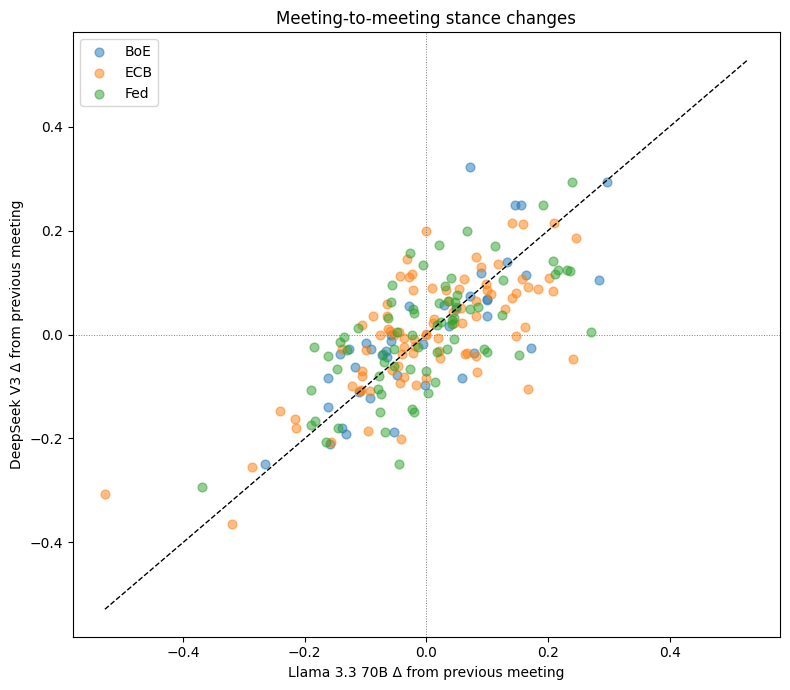

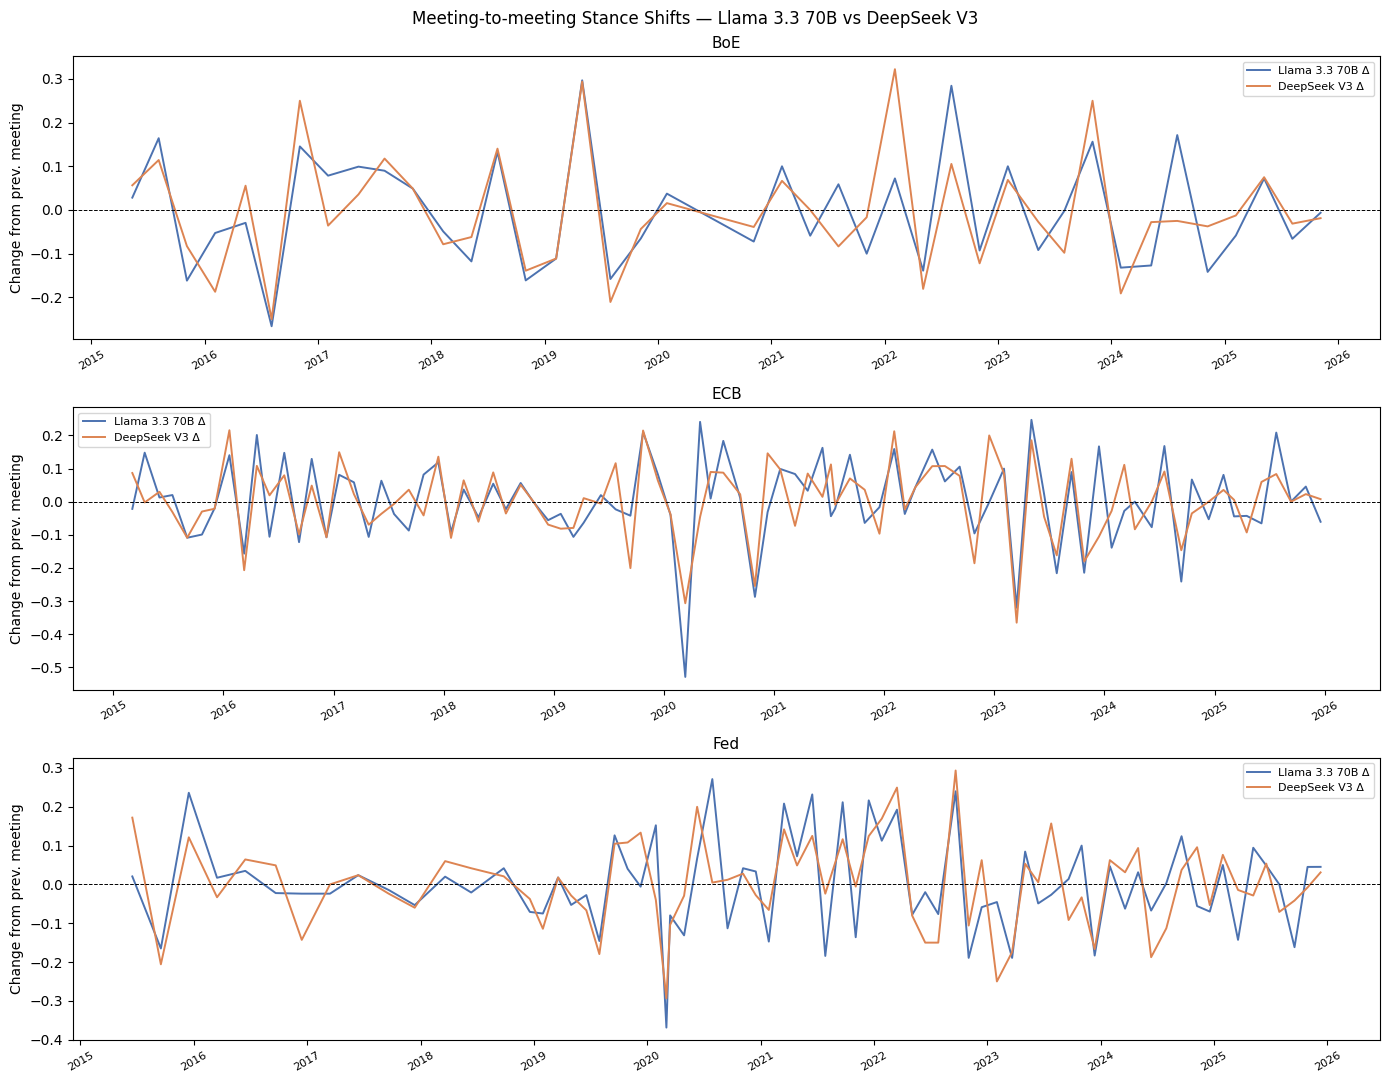


Meetings with largest shift disagreement:
bank       date  delta_llama33  delta_deepseekv3  shift_gap
 ECB 2020-04-30          0.241            -0.046      0.287
 ECB 2023-12-14          0.167            -0.105      0.272
 Fed 2020-07-29          0.271             0.005      0.267
 BoE 2022-02-03          0.072             0.322      0.250
 ECB 2020-03-12         -0.529            -0.306      0.222
 Fed 2023-02-01         -0.045            -0.250      0.205
 ECB 2022-12-15         -0.001             0.200      0.201
 BoE 2024-08-01          0.171            -0.025      0.196
 Fed 2020-01-29          0.152            -0.040      0.192
 Fed 2023-07-26         -0.027             0.157      0.184


C:\Users\sffra\AppData\Local\Temp\ipykernel_33384\812698450.py:57: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(wide.nlargest(10, 'shift_gap')[['bank','date',f'delta_{key_a}',f'delta_{key_b}','shift_gap']].round(3).to_string(index=False))


In [8]:
if len(loaded) >= 2:
    wide[f'delta_{key_a}'] = wide.groupby('bank')[key_a].diff()
    wide[f'delta_{key_b}'] = wide.groupby('bank')[key_b].diff()
    wide['shift_gap'] = (wide[f'delta_{key_a}'] - wide[f'delta_{key_b}']).abs()
    wide['same_shift_dir'] = np.where(
        wide[f'delta_{key_a}'].notna() & wide[f'delta_{key_b}'].notna(),
        np.sign(wide[f'delta_{key_a}']) == np.sign(wide[f'delta_{key_b}']),
        pd.NA,
    )

    shift_df = wide.dropna(subset=['shift_gap'])
    print('=== Delta summary by bank ===')
    print(shift_df.groupby('bank').agg(
        mean_level_gap=('score_gap','mean'),
        mean_shift_gap=('shift_gap','mean'),
        same_shift_dir_rate=('same_shift_dir', lambda x: pd.Series(x).dropna().astype(bool).mean()),
    ).round(3))

    # Scatter: delta_a vs delta_b
    plt.figure(figsize=(8, 7))
    for bank in BANKS:
        bdf = shift_df[shift_df['bank'] == bank]
        plt.scatter(bdf[f'delta_{key_a}'], bdf[f'delta_{key_b}'], label=bank, alpha=0.5, s=40)
    lim = max(shift_df[[f'delta_{key_a}',f'delta_{key_b}']].abs().max())
    plt.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1)
    plt.axhline(0, color='grey', linewidth=0.7, linestyle=':')
    plt.axvline(0, color='grey', linewidth=0.7, linestyle=':')
    plt.xlabel(f'{label_a} Δ from previous meeting')
    plt.ylabel(f'{label_b} Δ from previous meeting')
    plt.title('Meeting-to-meeting stance changes')
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'timeseries_delta_scatter_{out_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Time series of deltas by bank
    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)
    for ax, bank in zip(axes, BANKS):
        bdf = shift_df[shift_df['bank'] == bank].sort_values('date')
        ax.plot(bdf['date'], bdf[f'delta_{key_a}'], color=MODELS[key_a]['color'],
                linewidth=1.4, label=f'{label_a} Δ')
        ax.plot(bdf['date'], bdf[f'delta_{key_b}'], color=MODELS[key_b]['color'],
                linewidth=1.4, label=f'{label_b} Δ')
        ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
        ax.set_title(bank, fontsize=11)
        ax.set_ylabel('Change from prev. meeting')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.legend(fontsize=8)
    plt.suptitle(f'Meeting-to-meeting Stance Shifts — {label_a} vs {label_b}', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'timeseries_delta_{out_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nMeetings with largest shift disagreement:')
    print(wide.nlargest(10, 'shift_gap')[['bank','date',f'delta_{key_a}',f'delta_{key_b}','shift_gap']].round(3).to_string(index=False))

## 7. Semantic representation space

Embeds chunk text and projects to 2D to see whether disagreement clusters in semantic space.
Uses `sentence-transformers/all-MiniLM-L6-v2` with PCA fallback to TF-IDF + SVD.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/157 [00:00<?, ?it/s]

Representation: sentence-transformer + PCA
disagreement_type
agree                                      3881
deepseekv3 neutral, llama33 directional     630
other disagreement                          330
llama33 neutral, deepseekv3 directional     157
Name: count, dtype: int64


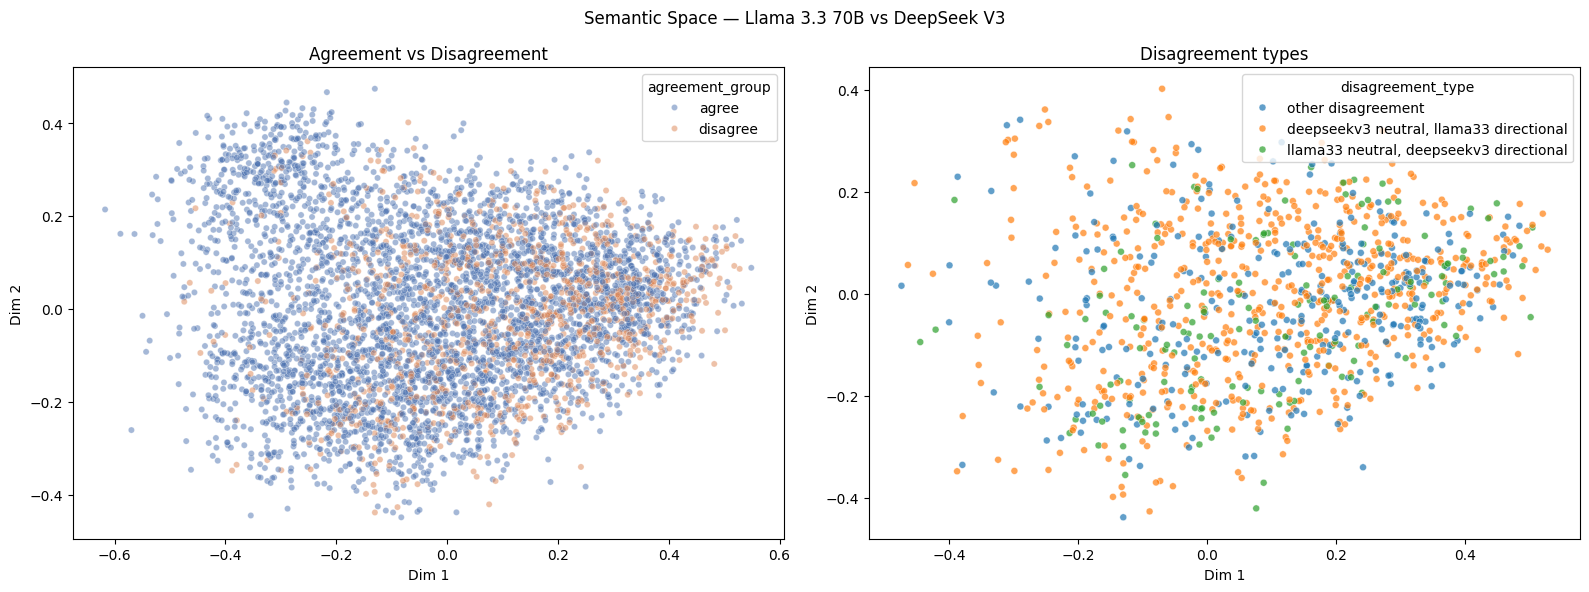

In [9]:
if len(loaded) >= 2:
    from sklearn.decomposition import PCA, TruncatedSVD
    from sklearn.feature_extraction.text import TfidfVectorizer

    repr_df = merged.copy()
    repr_df['agreement_group'] = np.where(repr_df['same_label'], 'agree', 'disagree')

    repr_df['disagreement_type'] = 'agree'
    repr_df.loc[
        (repr_df[f'label_{key_a}'] == 'neutral') & repr_df[f'label_{key_b}'].isin(DIRECTIONAL),
        'disagreement_type'
    ] = f'{key_a} neutral, {key_b} directional'
    repr_df.loc[
        (repr_df[f'label_{key_b}'] == 'neutral') & repr_df[f'label_{key_a}'].isin(DIRECTIONAL),
        'disagreement_type'
    ] = f'{key_b} neutral, {key_a} directional'
    repr_df.loc[
        (~repr_df['same_label']) & (repr_df['disagreement_type'] == 'agree'),
        'disagreement_type'
    ] = 'other disagreement'

    texts = repr_df['text'].fillna('').tolist()
    rep_source = 'tfidf_svd'
    try:
        from sentence_transformers import SentenceTransformer
        enc = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
        emb = enc.encode(texts, show_progress_bar=True)
        rep_2d = PCA(n_components=2, random_state=42).fit_transform(emb)
        rep_source = 'sentence-transformer + PCA'
    except Exception as e:
        print(f'Falling back to TF-IDF+SVD: {e}')
        tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2)
        X = tfidf.fit_transform(texts)
        rep_2d = TruncatedSVD(n_components=2, random_state=42).fit_transform(X)

    repr_df['rep_x'] = rep_2d[:, 0]
    repr_df['rep_y'] = rep_2d[:, 1]
    print(f'Representation: {rep_source}')
    print(repr_df['disagreement_type'].value_counts())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.scatterplot(data=repr_df, x='rep_x', y='rep_y', hue='agreement_group',
                    palette={'agree': '#4C72B0', 'disagree': '#DD8452'},
                    alpha=0.5, s=20, ax=axes[0])
    axes[0].set_title('Agreement vs Disagreement')
    axes[0].set_xlabel('Dim 1'); axes[0].set_ylabel('Dim 2')

    plot_df = repr_df[repr_df['disagreement_type'] != 'agree']
    sns.scatterplot(data=plot_df, x='rep_x', y='rep_y', hue='disagreement_type',
                    alpha=0.7, s=25, ax=axes[1])
    axes[1].set_title('Disagreement types')
    axes[1].set_xlabel('Dim 1'); axes[1].set_ylabel('Dim 2')

    plt.suptitle(f'Semantic Space — {label_a} vs {label_b}', fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'representation_space_{out_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Disagreement by linguistic features

Logistic regression: which chunk features (turn type, speaker role, keyword patterns) predict cross-model disagreement?

C:\Users\sffra\AppData\Local\Temp\ipykernel_33384\3550726058.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  model_df[col] = model_df['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\sffra\AppData\Local\Temp\ipykernel_33384\3550726058.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  model_df[col] = model_df['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\sffra\AppData\Local\Temp\ipykernel_33384\3550726058.py:23: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  model_df[col] = model_df['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)
C:\Users\sffra\AppData\Local\Temp\ipykernel_33384\3550726058.py:23: UserWarning: This pattern is int

In-sample ROC AUC: 0.685  (disagreement prevalence: 22.3%)


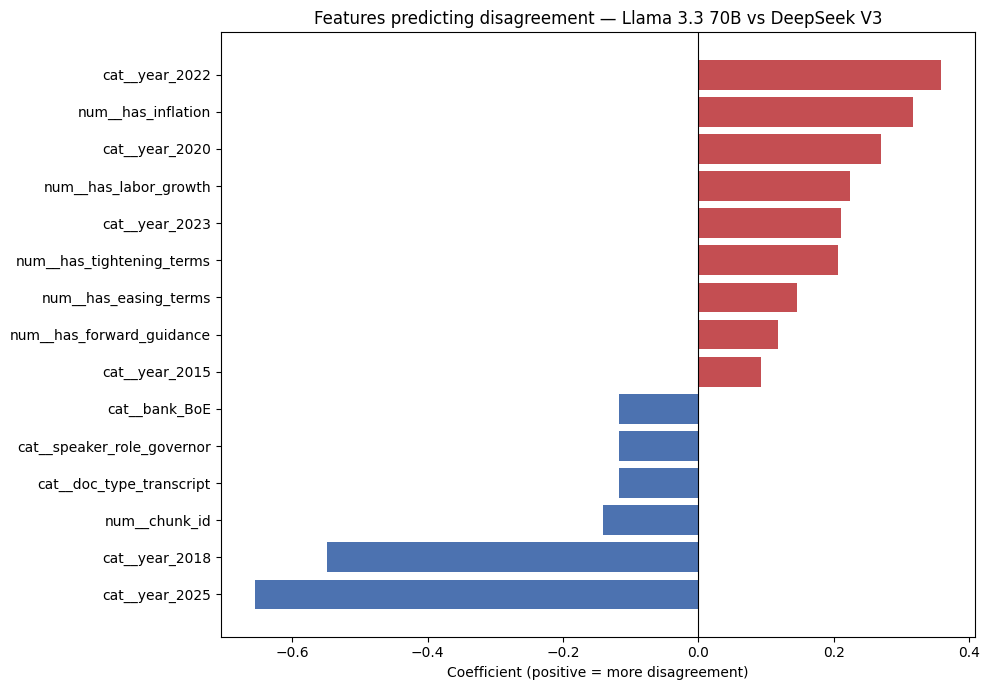


Top features by absolute coefficient:
                   feature   coef
            cat__year_2025 -0.655
            cat__year_2018 -0.549
            cat__year_2022  0.358
        num__has_inflation  0.317
            cat__year_2020  0.269
     num__has_labor_growth  0.224
            cat__year_2023  0.211
 num__has_tightening_terms  0.206
     num__has_easing_terms  0.145
             num__chunk_id -0.141
 num__has_forward_guidance  0.118
  cat__doc_type_transcript -0.117
cat__speaker_role_governor -0.117
             cat__bank_BoE -0.117
            cat__year_2015  0.092


In [10]:
if len(loaded) >= 2:
    from sklearn.compose import ColumnTransformer
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    model_df = merged.copy()
    model_df['disagree']    = (~model_df['same_label']).astype(int)
    model_df['word_count']  = model_df['text'].str.split().str.len()
    model_df['year']        = model_df['date'].dt.year.astype(str)

    PATTERNS = {
        'has_forward_guidance':  r'\b(will|would|expect|likely|path|trajectory|going forward)\b',
        'has_contrast_markers':  r'\b(but|however|although|while|on the other hand)\b',
        'has_inflation':         r'\b(inflation|prices|price stability|disinflation)\b',
        'has_labor_growth':      r'\b(growth|activity|demand|employment|labou?r market)\b',
        'has_risk_language':     r'\b(risk|uncertainty|upside|downside|balance of risks)\b',
        'has_tightening_terms':  r'\b(higher rates|raise rates|tighten|restrictive|hike)\b',
        'has_easing_terms':      r'\b(cut rates|lower rates|ease|accommodation|stimulus|qe)\b',
    }
    for col, pat in PATTERNS.items():
        model_df[col] = model_df['text'].str.contains(pat, case=False, regex=True, na=False).astype(int)

    num_cols = ['word_count', 'n_sentences', 'turn_idx', 'chunk_id'] + list(PATTERNS.keys())
    cat_cols = ['bank', 'speaker_role', 'turn_type', 'doc_type', 'year']

    X = model_df[num_cols + cat_cols].copy()
    y = model_df['disagree']

    clf = Pipeline([
        ('prep', ColumnTransformer([
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ])),
        ('logit', LogisticRegression(max_iter=5000, class_weight='balanced')),
    ])
    clf.fit(X, y)

    auc = roc_auc_score(y, clf.predict_proba(X)[:, 1])
    print(f'In-sample ROC AUC: {auc:.3f}  (disagreement prevalence: {y.mean():.1%})')

    feat_names = clf.named_steps['prep'].get_feature_names_out()
    coef_df = pd.DataFrame({'feature': feat_names, 'coef': clf.named_steps['logit'].coef_[0]})
    coef_df['abs_coef'] = coef_df['coef'].abs()
    coef_df = coef_df.sort_values('abs_coef', ascending=False)

    plt.figure(figsize=(10, 7))
    top = coef_df.head(15).sort_values('coef')
    colors = ['#C44E52' if c > 0 else '#4C72B0' for c in top['coef']]
    plt.barh(top['feature'], top['coef'], color=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Coefficient (positive = more disagreement)')
    plt.title(f'Features predicting disagreement — {label_a} vs {label_b}')
    plt.tight_layout()
    plt.savefig(OUT_DIR / f'disagreement_features_{out_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nTop features by absolute coefficient:')
    print(coef_df.head(15)[['feature','coef']].round(3).to_string(index=False))

## 9. Save

In [11]:
for key, meetings in all_meetings.items():
    out_path = OUT_DIR / f'meeting_scores_{key}.csv'
    meetings.to_csv(out_path, index=False)
    print(f'Saved -> {out_path}')

for key, meetings in all_meetings.items():
    print(f'\n{key}:')
    print(meetings.groupby('bank')[['net_hawk','mean_conf']].mean().round(3))

Saved -> C:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\output\stance\meeting_scores_llama33.csv
Saved -> C:\Users\sffra\Projects\BSE 2025-2026\central-bank-spillovers\output\stance\meeting_scores_deepseekv3.csv

llama33:
      net_hawk  mean_conf
bank                     
BoE      0.001      2.384
ECB     -0.083      2.556
Fed     -0.027      2.437

deepseekv3:
      net_hawk  mean_conf
bank                     
BoE      0.027      1.934
ECB     -0.040      2.161
Fed      0.022      2.154
